In [1]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
np.random.seed(42)

data = {
    "Study_Hours": np.random.randint(1, 11, 100),

    "Attendance": np.random.randint(50, 101, 100),

    "Assignment_Marks": np.random.randint(30, 101, 100),

    "Previous_Marks": np.random.randint(30, 101, 100),

    "Internal_Marks": np.random.randint(30, 101, 100)
}

df = pd.DataFrame(data)

df

,Study_Hours,Attendance,Assignment_Marks,Previous_Marks,Internal_Marks
0,7,61,31,33,30
1,4,83,83,64,45
2,8,82,30,93,90
3,5,97,48,78,93
4,7,72,31,46,92
...,...,...,...,...,...
95,10,86,93,30,45
96,9,98,98,87,98
97,7,66,90,30,41
98,9,98,77,63,54


In [6]:
score = (
    df["Study_Hours"] * 5 +
    df["Attendance"] * 0.3 +
    df["Assignment_Marks"] * 0.2 +
    df["Previous_Marks"] * 0.2 +
    df["Internal_Marks"] * 0.2
)

df["Result"] = np.where(score >= 65, "Pass", "Fail")

df

,Study_Hours,Attendance,Assignment_Marks,Previous_Marks,Internal_Marks,Result
0,7,61,31,33,30,Pass
1,4,83,83,64,45,Pass
2,8,82,30,93,90,Pass
3,5,97,48,78,93,Pass
4,7,72,31,46,92,Pass
...,...,...,...,...,...,...
95,10,86,93,30,45,Pass
96,9,98,98,87,98,Pass
97,7,66,90,30,41,Pass
98,9,98,77,63,54,Pass


In [7]:
print(df["Result"].value_counts())

Result
Pass    95
Fail     5
Name: count, dtype: int64


In [8]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Shape: (100, 6)

Missing Values:
Study_Hours         0
Attendance          0
Assignment_Marks    0
Previous_Marks      0
Internal_Marks      0
Result              0
dtype: int64

Duplicates:
0


In [9]:
X = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignment_Marks",
        "Previous_Marks",
        "Internal_Marks"
    ]
]

y = df["Result"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.92


In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.96


In [14]:
svm = SVC(
    kernel="rbf",
    C=1.0
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.96


In [15]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.92


In [16]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.92


In [17]:
depth_results = []

for depth in range(1, 11):

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    pred = tree.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    depth_results.append(accuracy)

    print(
        "Depth:", depth,
        "Accuracy:", accuracy
    )

Depth: 1 Accuracy: 0.96
Depth: 2 Accuracy: 0.92
Depth: 3 Accuracy: 0.92
Depth: 4 Accuracy: 0.92
Depth: 5 Accuracy: 0.92
Depth: 6 Accuracy: 0.92
Depth: 7 Accuracy: 0.92
Depth: 8 Accuracy: 0.92
Depth: 9 Accuracy: 0.92
Depth: 10 Accuracy: 0.92


In [20]:
results = pd.DataFrame({
    "Algorithm": [
        "Naive Bayes",
        "Random Forest",
        "SVM",
        "Decision Tree",
        "KNN"
      
    ],

    "Accuracy": [
        nb_accuracy,
        rf_accuracy,
        svm_accuracy,
        dt_accuracy,
        knn_accuracy
        
    ]
})

results

,Algorithm,Accuracy
0,Naive Bayes,0.92
1,Random Forest,0.96
2,SVM,0.96
3,Decision Tree,0.92
4,KNN,0.92


In [21]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Algorithm,Accuracy
1,Random Forest,0.96
2,SVM,0.96
0,Naive Bayes,0.92
3,Decision Tree,0.92
4,KNN,0.92


In [27]:
cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[ 0  1]
 [ 0 24]]


In [28]:
print("Naive Bayes")
print(classification_report(y_test, nb_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("SVM")
print(classification_report(y_test, svm_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("KNN")
print(classification_report(y_test, knn_pred))



Naive Bayes
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         1
        Pass       0.96      0.96      0.96        24

    accuracy                           0.92        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.92      0.92      0.92        25

Random Forest
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         1
        Pass       0.96      1.00      0.98        24

    accuracy                           0.96        25
   macro avg       0.48      0.50      0.49        25
weighted avg       0.92      0.96      0.94        25

SVM
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         1
        Pass       0.96      1.00      0.98        24

    accuracy                           0.96        25
   macro avg       0.48      0.50      0.49        25
weighted avg       0.92      0.96      0.94 

c:\Users\thema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\thema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\thema\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\thema\anaconda3\Lib\site-packag

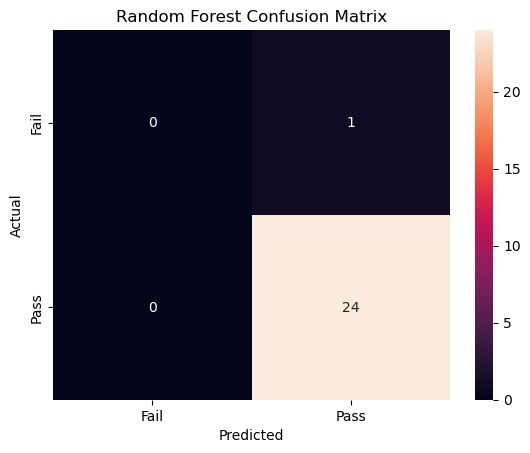

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [30]:
new_student = [[
    7,
    90,
    85,
    80,
    82
]]

In [31]:
nb_result = nb.predict(new_student)
rf_result = rf.predict(new_student)
dt_result = dt.predict(new_student)


c:\Users\thema\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\thema\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thema\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [32]:
new_student_scaled = scaler.transform(new_student)

svm_result = svm.predict(new_student_scaled)

knn_result = knn.predict(new_student_scaled)

c:\Users\thema\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
print("Naive Bayes:", nb_result[0])
print("Random Forest:", rf_result[0])
print("SVM:", svm_result[0])
print("Decision Tree:", dt_result[0])
print("KNN:", knn_result[0])


Naive Bayes: Pass
Random Forest: Pass
SVM: Pass
Decision Tree: Pass
KNN: Pass
